<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5221: Intelligent Image and Video Analysis</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Assessment 2: Neural Networks for Image Classification</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Student Name: Tristan Sim Yook Min</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Student ID: 30428831</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Task 1: Baseline Convolutional Neural Network (CNN) Model**




#### **Generate the Computing Environment**

In [55]:
import sys
import tensorflow as tf
import platform
import psutil
import subprocess

print(f"Python Version          : {sys.version}")
print(f"TensorFlow Version      : {tf.__version__}")
print(f"Keras Version           : {tf.keras.__version__}")
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,memory.free', '--format=csv,noheader'], capture_output=True, text=True)
print(f"GPU Info                : {result.stdout.strip()}")
print(f"CUDA Version            : {tf.sysconfig.get_build_info()['cuda_version']}")
ram = psutil.virtual_memory()
print(f"Total RAM               : {ram.total / (1024**3):.2f} GB")
print(f"Operating System        : {platform.system()} {platform.release()}")

Python Version          : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow Version      : 2.20.0
Keras Version           : 3.13.2
GPU Info                : Tesla T4, 15360 MiB, 10676 MiB
CUDA Version            : 12.5.1
Total RAM               : 12.67 GB
Operating System        : Linux 6.6.122+


#### **Import the Task 1 Libraries**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

#### **Load the CIFAR-100 Dataset**

In [3]:
cifar100 = tf.keras.datasets.cifar100
(train_images, train_labels), (test_images, test_labels) = cifar100.load_data()

# Normalize pixel values to values 0.0 to 1.0
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

print("Train images shape:", train_images.shape)
print("Test images shape:", test_images.shape)
print("Number of classes:", len(np.unique(train_labels)))

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train images shape: (50000, 32, 32, 3)
Test images shape: (10000, 32, 32, 3)
Number of classes: 100


### **Build the Convolutional Neural Network (CNN)**

The diagram below shows the architecture of the Baseline Convolutional Neural Network (CNN).

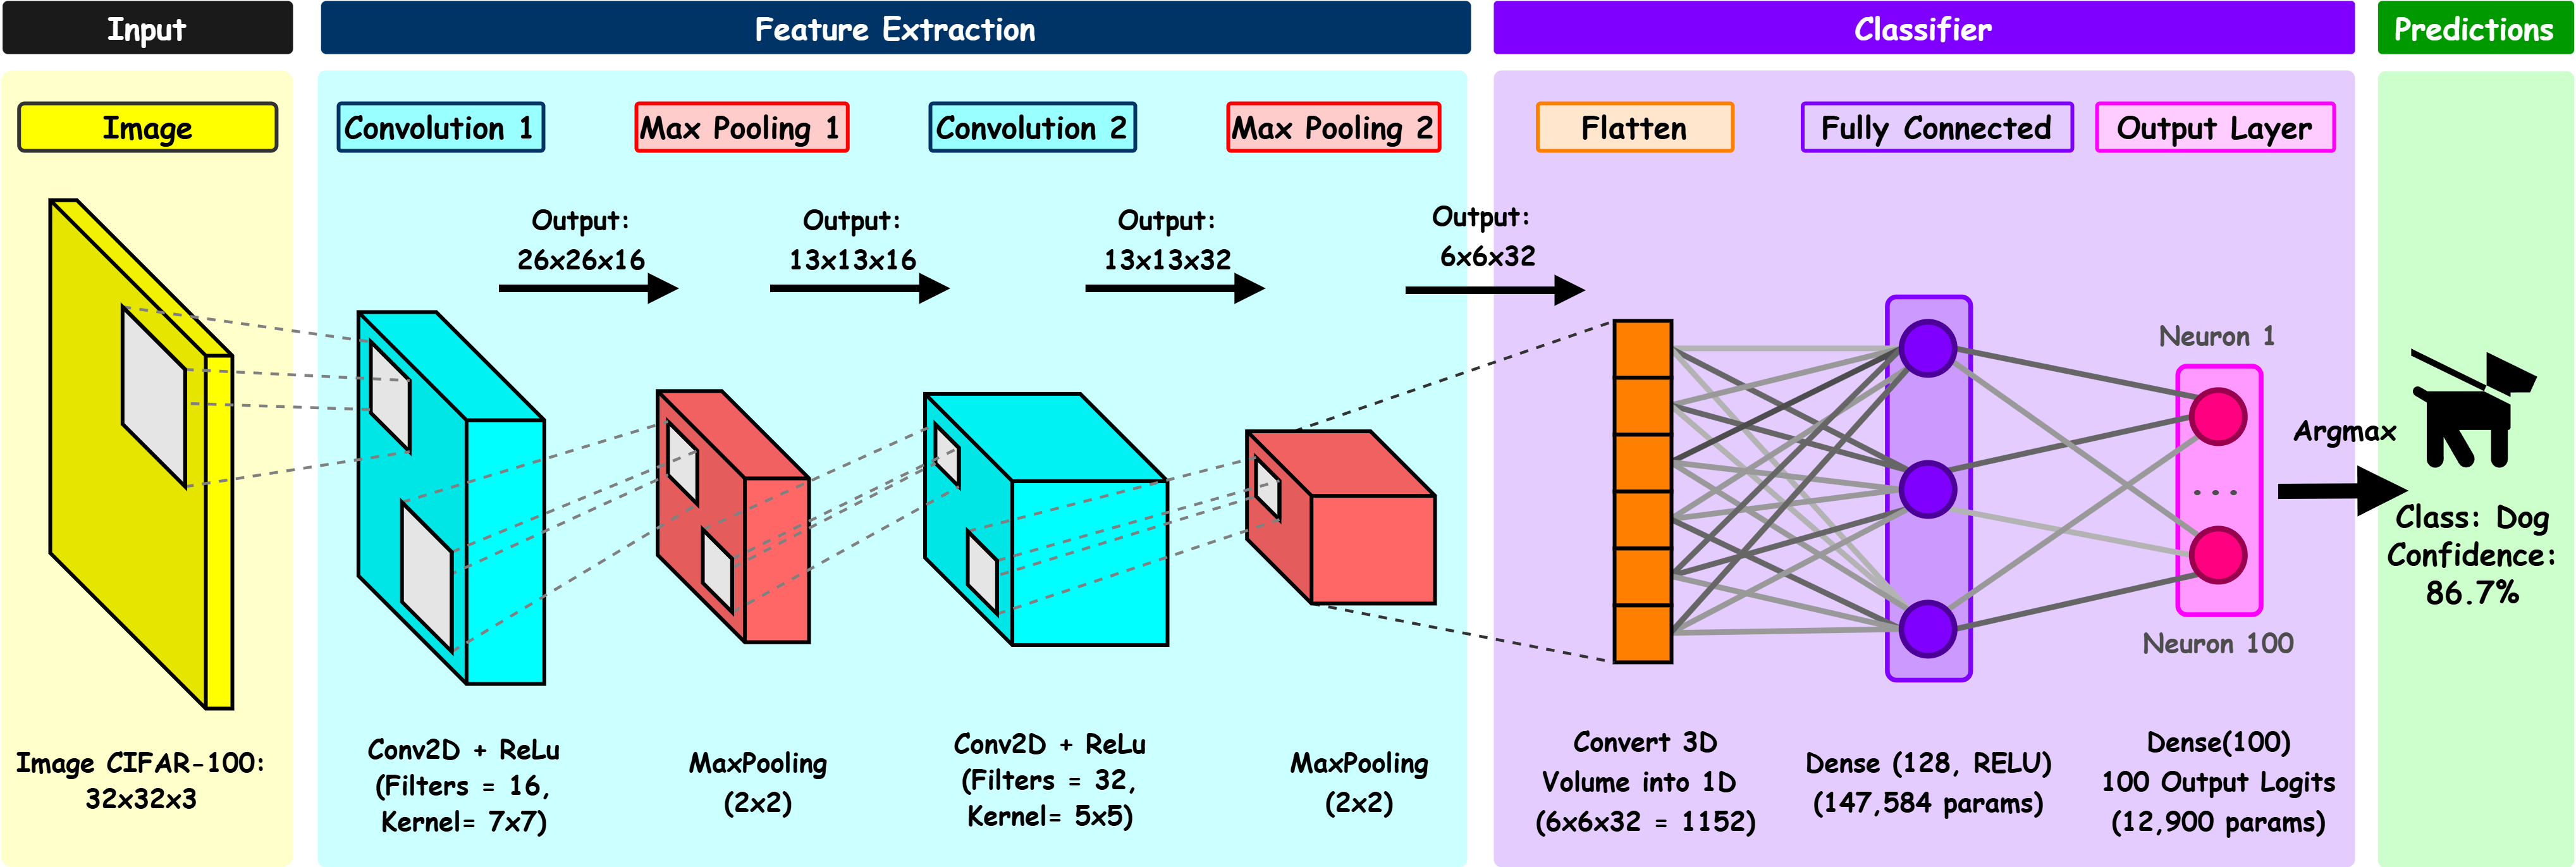

In [4]:
baseline_model = Sequential([

    # Input: Image CIFAR-100 of matrix dimension 32x32 pixels and 3 RGB
    Input(shape=(32, 32, 3)),

    # Feature Extraction:
    # Convolutional Neural Network Block 1:
    # Specification: Filter = 16, Kernels = 7x7, Stride = 1, Padding = Valid, Activation Function = ReLU
    Conv2D(16, kernel_size=7, strides=1, padding='valid', activation='relu'),
    MaxPooling2D(pool_size=2, strides=2),
    # Convolutional Neural Network Block 2:
    # Specification: Filter = 32, Kernels = 5x5, Stride = 1, Padding = Valid, Activation Function = ReLU
    Conv2D(32, kernel_size=5, strides=1, padding='same', activation='relu'),
    MaxPooling2D(pool_size=2, strides=2),

    # Classifier:
    # Specification: Flatten Matrix (6, 6, 32) to 1152 values, Dense(128, ReLu), 100 OutPUT Logits
    Flatten(), Dense(128, activation='relu'), Dense(100)
])

print(baseline_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,684 (686.27 KB)

 Trainable params: 175,684 (686.27 KB)

 Non-trainable params: 0 (0.00 B)

None


#### **Compile and Train the Model**

In [ ]:
learning_rate_scheldule = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate = 0.001,decay_steps = 25*(50000//64))

# Compile the Model
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate = learning_rate_scheldule),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics=['accuracy']
)

# Train the Model
history_baseline = baseline_model.fit(
    train_images, train_labels,
    epochs = 25,
    batch_size = 128,
    validation_data = (test_images, test_labels),
    verbose = 1
)

#### **Evaluate the Model on the Test Dataset**

In [56]:
loss_baseline, accuracy_baseline = baseline_model.evaluate(test_images, test_labels, verbose=0)

print(f"Best Training Accuracy : {max(history_baseline.history['accuracy']) * 100:.2f}%")
print(f"Best Training Loss     : {min(history_baseline.history['loss']):.4f}")
print(f"Best Test Accuracy     : {accuracy_baseline * 100:.2f}%")
print(f"Best Test Loss         : {loss_baseline:.4f}")

Best Training Accuracy : 56.08%
Best Training Loss     : 1.6397
Best Test Accuracy     : 35.04%
Best Test Loss         : 2.8844


#### **Plot the Accuracy and Loss Curves of the Model**

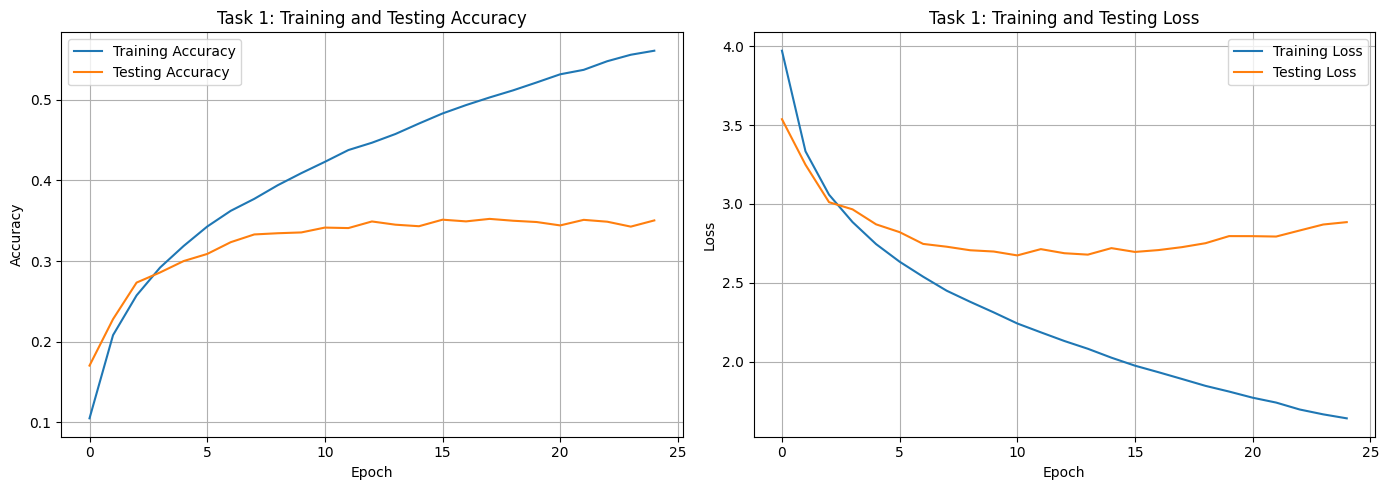

In [57]:
figure, (axis_1, axis_2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot on the Left Side
axis_1.plot(history_baseline.history['accuracy'], label='Training Accuracy')
axis_1.plot(history_baseline.history['val_accuracy'], label='Testing Accuracy')
axis_1.set_title('Task 1: Training and Testing Accuracy')
axis_1.set_xlabel('Epoch')
axis_1.set_ylabel('Accuracy')
axis_1.legend()
axis_1.grid(True)

# Loss plot on the Right Side
axis_2.plot(history_baseline.history['loss'], label='Training Loss')
axis_2.plot(history_baseline.history['val_loss'], label='Testing Loss')
axis_2.set_title('Task 1: Training and Testing Loss')
axis_2.set_xlabel('Epoch')
axis_2.set_ylabel('Loss')
axis_2.legend()
axis_2.grid(True)

plt.tight_layout()
plt.show()

***

### **Task 2: Improve the Baseline Model**

Task 2 will explore different variation of the Model by adjusting various parameters and configuration to improve the Model performances. To simplify the process, a method has been created to a Train and Evaluate which can be easily called to compile, train and evaluate the models.

In [8]:
def train_and_evaluate(model, model_name, epochs = 20, batch_size = 128):
    """
    This Method Trains the Model and Evaluates the Results of the Model by Printing the best Test Dataset Accuracy.
    It also generates the Training and Test Dataset Accuracy and Loss Plot.

    Args:
       model: The Custom CNN Model passed into the Method to be Compiled, Trained and Evaluated
       model_name (String): The name of the model
       epochs (Int): The number of Epochs to Train the Model
       batch_size (Int): Number of Training Samples Processed in a Single Forward and Backward Pass until the Model updates its weights

    Returns:
       training_history (List): Training History of the Model
       highest_test_accuracy (Float): Highest Test Dataset Accuracy
    """

    # Compile the Models
    model.compile(
        optimizer='adam',
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    # Train the Models
    training_history = model.fit(
        train_images, train_labels,
        epochs = epochs,
        batch_size = batch_size,
        validation_data = (test_images, test_labels),
        verbose = 1
    )

    # Record the Highest Test Dataset Accuracy and which Epoch it occurred
    highest_test_accuracy = max(training_history.history['val_accuracy'])
    epoch_occurance = training_history.history['val_accuracy'].index(highest_test_accuracy) + 1

    # Generate the Accuracy and Loss Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(training_history.history['accuracy'], label='Training Accuracy')
    ax1.plot(training_history.history['val_accuracy'], label='Testing Accuracy')
    ax1.set_title(f'{model_name}: Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(training_history.history['loss'], label='Training Loss')
    ax2.plot(training_history.history['val_loss'], label='Testing Loss')
    ax2.set_title(f'{model_name}: Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # Print the Reuslts and Model Summary
    print(f"Model Name: {model_name}")
    print(f"Highest Test Dataset Accuracy: {highest_test_accuracy*100:.2f}%")
    print(f"Highest Accuracy occured at Epoch: {epoch_occurance}")
    print(model.summary())

    return training_history, highest_test_accuracy

#### **Variant 1A: Light Data Augmentation**

In the first variant, light data augmentation is introduced directly after the input layer. RandomFlip randomly mirrors the image left-to-right, and RandomRotation rotates the image randomly by ±10% of 360 degrees, which equates to approximately ±36 degrees. This randomisation artificially increases the effective dataset size by exposing the model to slightly different versions of the same image during each training epoch, helping to reduce overfitting.

The remaining architecture is identical to the baseline CNN, with the same two convolutional blocks, flatten layer, and fully connected layers.

In [ ]:
model_V1A_name = "Variant 1A: Light Data Augmentation"

data_V1A = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
])

model_V1A = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    data_V1A,
    Conv2D(16, 7, strides=1, padding='valid', activation='relu'),
    MaxPooling2D(2, strides=2),
    Conv2D(32, 5, strides=1, padding='same', activation='relu'),
    MaxPooling2D(2, strides=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(100)
])

history_V1A, accuracy_V1A = train_and_evaluate(model_V1A, model_V1A_name)

#### **Variant 1B: Heavier Data Augmentation**

In the second variant, a more aggressive data augmentation pipeline is applied. RandomFlip continues to randomly mirror the image left-to-right. RandomRotation is increased slightly to ±15% of 360 degrees (approximately ±54 degrees), introducing more rotational variety than the first variant. RandomZoom randomly zooms into the image by up to 10%, simulating objects appearing at different scales. RandomContrast randomly adjusts the contrast of the image by up to 20%, making the model more robust to variations in lighting and colour intensity.

The remaining architecture is identical to the baseline CNN, with the same two convolutional blocks, flatten layer, and fully connected layers.

In [ ]:
model_V1B_name = "Variant 1B: Heavy Data Augmentation"

data_V1B = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2),
])

model_V1B = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    data_V1B,
    Conv2D(16, 7, strides=1, padding='valid', activation='relu'),
    MaxPooling2D(2, strides=2),
    Conv2D(32, 5, strides=1, padding='same', activation='relu'),
    MaxPooling2D(2, strides=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(100)
])

history_V1B, accuracy_V1B = train_and_evaluate(model_V1B, model_V1B_name)

#### **Variant 2A: Batch Normalization after each Convolutional Layer**

In the first variant of normalisation, Batch Normalisation is applied after each convolutional layer, before the ReLU activation. This follows the order of Conv2D, then BatchNorm, then ReLU. This normalises the output of each convolutional layer by adjusting and scaling the activations, helping to stabilise training and reduce the sensitivity to weight initialisation.

The remaining architecture is identical to the baseline CNN, with the same two convolutional blocks, flatten layer, and fully connected layers.

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.1320 - loss: 3.7895 - val_accuracy: 0.1422 - val_loss: 3.6699
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2365 - loss: 3.1277 - val_accuracy: 0.2207 - val_loss: 3.1892
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2955 - loss: 2.8171 - val_accuracy: 0.2560 - val_loss: 3.0478
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3375 - loss: 2.6267 - val_accuracy: 0.2726 - val_loss: 3.0301
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3642 - loss: 2.5012 - val_accuracy: 0.3190 - val_loss: 2.7033
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3841 - loss: 2.3962 - val_accuracy: 0.2775 - val_loss: 2.9725
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4012 - loss: 2.3174 - val_accuracy: 0.2958 - val_loss: 2.9359
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4200 - loss: 2.2405 - val_accuracy: 0

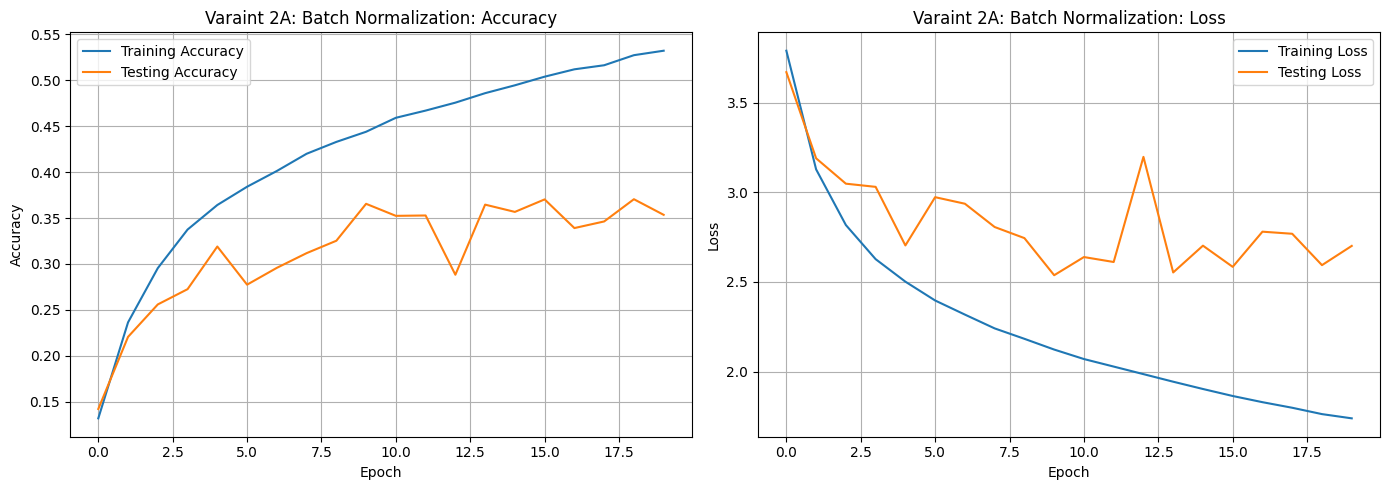

Model Name: Varaint 2A: Batch Normalization
Highest Test Dataset Accuracy: 37.05%
Highest Accuracy occured at Epoch: 19


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 16)     │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 26, 26, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 527,438 (2.01 MB)

 Trainable params: 175,780 (686.64 KB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 351,562 (1.34 MB)

None


In [11]:
model_V2A_name = "Varaint 2A: Batch Normalization"

model_V2A = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    Conv2D(16, 7, strides=1, padding='valid'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    MaxPooling2D(2, strides=2),
    Conv2D(32, 5, strides=1, padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    MaxPooling2D(2, strides=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(100)
])

history_V2A, accuracy_V2A = train_and_evaluate(model_V2A, model_V2A_name)

#### **Variant 2B: Dropout after Dense and after each Convolutional Layer**

In the second variant of normalisation, Dropout is applied after each convolutional layer and after the fully connected Dense layer. After each convolutional layer, a Dropout rate of 0.25 is used, meaning 25% of neurons are randomly deactivated during each training step. A higher Dropout rate of 0.5 is applied after the Dense layer of 128 neurons, meaning 50% of neurons are randomly deactivated. This forces the model to not rely on any single neuron, reducing overfitting and improving generalisation.

The remaining architecture is identical to the baseline CNN, with the same two convolutional blocks, flatten layer, and fully connected layers.

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.0388 - loss: 4.3552 - val_accuracy: 0.1011 - val_loss: 4.0805
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1049 - loss: 3.8815 - val_accuracy: 0.1553 - val_loss: 3.8007
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1462 - loss: 3.6270 - val_accuracy: 0.2066 - val_loss: 3.5504
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1713 - loss: 3.4786 - val_accuracy: 0.2138 - val_loss: 3.4703
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1878 - loss: 3.3876 - val_accuracy: 0.2339 - val_loss: 3.3854
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2009 - loss: 3.3113 - val_accuracy: 0.2508 - val_loss: 3.3013
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2131 - loss: 3.2467 - val_accuracy: 0.2621 - val_loss: 3.2528
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2210 - loss: 3.1922 - val_accuracy: 

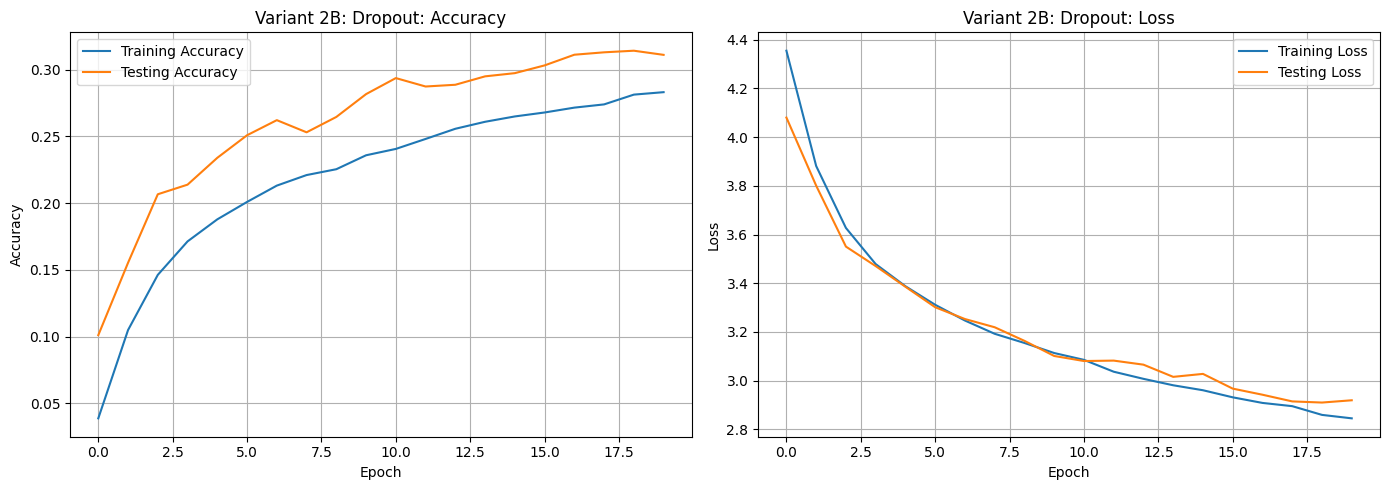

Model Name: Variant 2B: Dropout
Highest Test Dataset Accuracy: 31.41%
Highest Accuracy occured at Epoch: 19


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 16)     │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 26, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 527,054 (2.01 MB)

 Trainable params: 175,684 (686.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 351,370 (1.34 MB)

None


In [12]:
from tensorflow.keras.layers import Dropout

model_V2B_name = "Variant 2B: Dropout"

model_V2B = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    Conv2D(16, 7, strides=1, padding='valid', activation='relu'),
    Dropout(0.25),
    MaxPooling2D(2, strides=2),
    Conv2D(32, 5, strides=1, padding='same', activation='relu'),
    Dropout(0.25),
    MaxPooling2D(2, strides=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(100)
])

history_V2B, accuracy_V2B = train_and_evaluate(model_V2B, model_V2B_name)

#### **Variant 3A: Smaller Kernels and More Filters**

In the first variant of filter and size changes, both the kernel size and number of filters are modified from the baseline. The kernel size is reduced from 7x7 to 3x3 in the first convolutional layer and from 5x5 to 3x3 in the second convolutional layer. The number of filters is increased from 16 to 32 in the first convolutional layer and from 32 to 64 in the second convolutional layer. Smaller kernels capture finer and more localised features, while more filters allow the model to learn a greater variety of features at each layer.

The remaining architecture is identical to the baseline CNN, with the same two convolutional blocks, flatten layer, and fully connected layers.

In [ ]:
model_V3A_name = "Variant 3A: Smaller Kernels and More Filters"

model_V3A = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    Conv2D(32, 3, strides=1, padding='same', activation='relu'),
    MaxPooling2D(2, strides=2),
    Conv2D(64, 3, strides=1, padding='same', activation='relu'),
    MaxPooling2D(2, strides=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(100)
])

history_V3A, accuracy_V3A = train_and_evaluate(model_V3A, model_V3A_name)

#### **Variant 3B: More Filters with Smaller Kernels**

In the second variant of filter and size changes, the kernel size remains at 3x3 for both convolutional layers, consistent with the first variant. However, the number of filters is further increased, from 32 to 64 in the first convolutional layer and from 64 to 128 in the second convolutional layer. This allows the model to learn a much greater variety of features at each layer, at the cost of increased computational complexity and a higher number of parameters.

The remaining architecture is identical to the baseline CNN, with the same two convolutional blocks, flatten layer, and fully connected layers.

In [ ]:
model_V3B_name = "More Filters with Smaller Kernels"

model_V3B = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    Conv2D(64, 3, strides=1, padding='same', activation='relu'),
    MaxPooling2D(2, strides=2),
    Conv2D(128, 3, strides=1, padding='same', activation='relu'),
    MaxPooling2D(2, strides=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(100)
])

history_V3B, accuracy_V3B = train_and_evaluate(model_V3B, model_V3B_name)

#### **Variant 4A: 4 Convolutional Layers**

In the first variant of adding more layers, the number of convolutional layers is doubled from two to four. Two convolutional layers with 16 filters and a 3x3 kernel are stacked before the first MaxPooling layer, and two convolutional layers with 32 filters and a 3x3 kernel are stacked before the second MaxPooling layer. Stacking two convolutional layers before each pooling operation allows the model to learn more complex and abstract features before the spatial dimensions are reduced, potentially improving the model's ability to distinguish between the 100 classes.

The remaining architecture is identical to the baseline CNN, with the same flatten layer and fully connected layers.

In [ ]:
model_V4A_name = "Variant 4A: 4 Convolutional Layers"

model_V4A = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    Conv2D(16, 3, strides=1, padding='same', activation='relu'),
    Conv2D(16, 3, strides=1, padding='same', activation='relu'),
    MaxPooling2D(2, strides=2),
    Conv2D(32, 3, strides=1, padding='same', activation='relu'),
    Conv2D(32, 3, strides=1, padding='same', activation='relu'),
    MaxPooling2D(2, strides=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(100)
])

history_V4A, accuracy_v4A = train_and_evaluate(model_V4A, model_V4A_name)

#### **Variant 4B: 6 Convolutional Layers with Increasing Filters**

In the second variant of adding more layers, a third convolutional block is added, bringing the total to six convolutional layers. Each block contains two convolutional layers with a 3x3 kernel, followed by a MaxPooling layer. The number of filters increases progressively across the three blocks, from 16 in the first block, to 32 in the second block, and to 64 in the third block. This progressive increase follows the principle that deeper layers require more filters to capture increasingly complex and abstract features, while earlier layers only need fewer filters for simpler low-level features such as edges and colours.

The remaining flatten layer and fully connected layers are identical to the baseline.

In [ ]:
model_V4B_name = "Variant 4B: 6 Convolutional Layers with Increasing Filters"

model_V4B = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    Conv2D(16, 3, strides=1, padding='same', activation='relu'),
    Conv2D(16, 3, strides=1, padding='same', activation='relu'),
    MaxPooling2D(2, strides=2),
    Conv2D(32, 3, strides=1, padding='same', activation='relu'),
    Conv2D(32, 3, strides=1, padding='same', activation='relu'),
    MaxPooling2D(2, strides=2),
    Conv2D(64, 3, strides=1, padding='same', activation='relu'),
    Conv2D(64, 3, strides=1, padding='same', activation='relu'),
    MaxPooling2D(2, strides=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(100)
])

history_V4B, accuracy_V4B = train_and_evaluate(model_V4B, model_V4B_name)

#### **Variant 5A: Residual Block (1 Block per Stage)**

In the first variant of residual blocks, one residual block is added after the initial convolutional layer in each of the two stages. Each residual block consists of two convolutional layers with a 3x3 kernel, where the input to the block is preserved as a skip connection and added back to the output before the final ReLU activation. If the number of filters between the input and output does not match, a 1x1 convolution is applied to the skip connection to project it to the correct number of channels. This allows gradients to flow more directly through the network during backpropagation, helping to address the vanishing gradient problem and enabling the model to learn residual mappings rather than direct mappings.

The remaining architecture is identical to the baseline CNN, with the same flatten layer and fully connected layers.

In [ ]:
from tensorflow.keras.layers import Add, Input
from tensorflow.keras import Model

model_V5A_name = "Variant 5A: Residual Block (1 block per stage)"

def residual_block(x, filters, kernel_size=3):
    skip_connection = x  # Save input tensor for the skip connection
    x = Conv2D(filters, kernel_size, padding='same', activation='relu')(x)  # First Conv layer
    x = Conv2D(filters, kernel_size, padding='same')(x)                     # Second Conv layer
    # If channel mismatch, apply 1x1 convolution to project skip connection to matching shape
    if skip_connection.shape[-1] != filters:
        skip_connection = Conv2D(filters, 1, padding='same')(skip_connection)
    x = Add()([x, skip_connection])      # Add skip connection to main path output
    x = tf.keras.layers.ReLU()(x)        # Apply ReLU after addition
    return x

inputs = Input(shape=(32, 32, 3))
x = Conv2D(16, 3, padding='same', activation='relu')(inputs)
x = residual_block(x, 16) # Residual Block Stage 1
x = MaxPooling2D(2, strides=2)(x)
x = Conv2D(32, 3, padding='same', activation='relu')(x)
x = residual_block(x, 32) # Residual Block Stage 2
x = MaxPooling2D(2, strides=2)(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(100)(x)

model_V5A = Model(inputs, outputs)
history_V5A, accuracy_V5A = train_and_evaluate(model_V5A, model_V5A_name)

#### **Variant 5B: Residual Block (2 blocks per Stage and 32-64 Filters)**

In the second variant of residual blocks, the number of residual blocks per stage is doubled from one to two, and the number of filters is increased. The first stage uses 32 filters with two residual blocks, and the second stage uses 64 filters with two residual blocks. Stacking two residual blocks per stage allows the model to learn deeper and more complex feature representations before each pooling operation, whilst the increased filter count allows more feature variety to be captured at each stage.

The remaining architecture is identical to the baseline CNN, with the same flatten layer and fully connected layers.

In [ ]:
model_V5B_name = "Variant 5B: Residual Block (2 blocks per Stage and 32-64 Filters)"

inputs = Input(shape=(32, 32, 3))
x = Conv2D(32, 3, padding='same', activation='relu')(inputs)
x = residual_block(x, 32)  # Residual Block 1 at Stage 1
x = residual_block(x, 32)  # Residual Block 2 at Stage 1
x = MaxPooling2D(2, strides=2)(x)
x = Conv2D(64, 3, padding='same', activation='relu')(x)
x = residual_block(x, 64)  # Residual Block 1 at Stage 2
x = residual_block(x, 64)  # Residual Block 2 at Stage 2
x = MaxPooling2D(2, strides=2)(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(100)(x)

model_V5B = Model(inputs, outputs)
history_V5B, accuracy_V5B = train_and_evaluate(model_V5B, model_V5B_name)

#### **Variant 6A: Simple Three-Path Inception Module**

In the first variant of inception modules, a simple three-path inception module is applied after each initial convolutional layer. Each inception module processes the input simultaneously through three parallel convolutional paths: a 1x1 convolution, a 3x3 convolution, and a 5x5 convolution. The outputs of all three paths are then concatenated along the filter dimension. This allows the model to capture features at multiple scales simultaneously within the same layer. The first inception module uses 8, 16, and 8 filters for the 1x1, 3x3, and 5x5 paths respectively, and the second uses 16, 32, and 16 filters.

The remaining architecture is identical to the baseline CNN, with the same flatten layer and fully connected layers.

In [ ]:
from tensorflow.keras.layers import Concatenate

model_V6A_name = "Variant 6A: Simple Three-Path Inception Module"

def inception_module(x, f1x1, f3x3, f5x5):
    path1 = Conv2D(f1x1, 1, padding='same', activation='relu')(x)  # 1x1 path for Fine details and channel relationships
    path2 = Conv2D(f3x3, 3, padding='same', activation='relu')(x)  # 3x3 path for Medium scale features
    path3 = Conv2D(f5x5, 5, padding='same', activation='relu')(x)  # 5x5 path for Larger scale features
    return Concatenate()([path1, path2, path3])                    # Concatenate all paths

inputs = Input(shape=(32, 32, 3))
x = Conv2D(16, 3, padding='same', activation='relu')(inputs)
x = inception_module(x, f1x1=8, f3x3=16, f5x5=8)    # Inception Module 1
x = MaxPooling2D(2, strides=2)(x)
x = inception_module(x, f1x1=16, f3x3=32, f5x5=16)  # Inception Module 2
x = MaxPooling2D(2, strides=2)(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(100)(x)

model_V6A = Model(inputs, outputs)
history_V6A, accuracy_V6A = train_and_evaluate(model_V6A, model_V6A_name)

#### **Variant 6B: Inception Module with 1x1 Dimensionality Reduction**

In the second variant of inception modules, a 1x1 reduction convolution is introduced before the 3x3 and 5x5 convolutional paths. Rather than applying the larger convolutions directly to the input, a smaller 1x1 convolution first reduces the number of channels, lowering the computational cost before the more expensive 3x3 and 5x5 convolutions are applied. In the first inception module, the 3x3 path uses a 1x1 reduction of 16 filters followed by 32 filters, and the 5x5 path uses a 1x1 reduction of 8 filters followed by 16 filters. In the second inception module, these are increased to 32 and 64 filters for the 3x3 path, and 16 and 32 filters for the 5x5 path. This design is inspired by the original GoogLeNet architecture and allows the model to capture multi-scale features more efficiently.

The remaining architecture is identical to the baseline CNN, with the same flatten layer and fully connected layers.

In [ ]:
model_V6B_name = "Variant 6B: Inception Module with 1x1 Dimensionality Reduction"

def inception_module_v2(x, f1x1, f3x3_reduce, f3x3, f5x5_reduce, f5x5):
    path1 = Conv2D(f1x1, 1, padding='same', activation='relu')(x)              # 1x1 path
    path2 = Conv2D(f3x3_reduce, 1, padding='same', activation='relu')(x)       # 1x1 reduction
    path2 = Conv2D(f3x3, 3, padding='same', activation='relu')(path2)          # 3x3 path
    path3 = Conv2D(f5x5_reduce, 1, padding='same', activation='relu')(x)       # 1x1 reduction
    path3 = Conv2D(f5x5, 5, padding='same', activation='relu')(path3)          # 5x5 path
    return Concatenate()([path1, path2, path3])                               # Concatenate all paths

inputs = Input(shape=(32, 32, 3))
x = Conv2D(32, 3, padding='same', activation='relu')(inputs)
x = inception_module_v2(x, f1x1=16, f3x3_reduce=16, f3x3=32, f5x5_reduce=8, f5x5=16)   # Inception Module 1
x = MaxPooling2D(2, strides=2)(x)
x = inception_module_v2(x, f1x1=32, f3x3_reduce=32, f3x3=64, f5x5_reduce=16, f5x5=32)  # Inception Module 2
x = MaxPooling2D(2, strides=2)(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(100)(x)

model_V6B = Model(inputs, outputs)
history_V6B, accuracy_V6B = train_and_evaluate(model_V6B, model_V6B_name)

#### **Task 2 Models Result Summary**

The Task 2 Model Variatns and the Performance Results are summarize and tabulauted using Pandas Dataframe for better visualization.

In [58]:
import pandas as pd

def get_best_acc(history, split='val'):
    key = 'accuracy' if split == 'accuracy' else f'{split}_accuracy'
    return round(max(history.history[key]) * 100, 2)

def get_best_loss(history, split='val'):
    key = 'loss' if split == 'loss' else f'{split}_loss'
    return round(min(history.history[key]), 4)

results = {
    "Variant": [
        "Baseline (Task 1)",
        model_V1A_name, model_V1B_name, model_V2A_name, model_V2B_name, model_V3A_name, model_V3B_name,
        model_V4A_name, model_V4B_name, model_V5A_name, model_V5B_name, model_V6A_name, model_V6B_name,
    ],
    "Highest Training Accuracy (%)": [
        round(max(history_baseline.history['accuracy']) * 100, 2),
        get_best_acc(history_V1A, 'accuracy'), get_best_acc(history_V1B, 'accuracy'),
        get_best_acc(history_V2A, 'accuracy'), get_best_acc(history_V2B, 'accuracy'),
        get_best_acc(history_V3A, 'accuracy'), get_best_acc(history_V3B, 'accuracy'),
        get_best_acc(history_V4A, 'accuracy'), get_best_acc(history_V4B, 'accuracy'),
        get_best_acc(history_V5A, 'accuracy'), get_best_acc(history_V5B, 'accuracy'),
        get_best_acc(history_V6A, 'accuracy'), get_best_acc(history_V6B, 'accuracy'),
    ],
    "Highest Test Accuracy (%)": [
        round(accuracy_baseline * 100, 2),
        round(accuracy_V1A * 100, 2), round(accuracy_V1B * 100, 2),
        round(accuracy_V2A * 100, 2), round(accuracy_V2B * 100, 2),
        round(accuracy_V3A * 100, 2), round(accuracy_V3B * 100, 2),
        round(accuracy_v4A * 100, 2), round(accuracy_V4B * 100, 2),
        round(accuracy_V5A * 100, 2), round(accuracy_V5B * 100, 2),
        round(accuracy_V6A * 100, 2), round(accuracy_V6B * 100, 2),
    ],
    "Lowest Training Loss": [
        get_best_loss(history_baseline, 'loss'),
        get_best_loss(history_V1A, 'loss'), get_best_loss(history_V1B, 'loss'),
        get_best_loss(history_V2A, 'loss'), get_best_loss(history_V2B, 'loss'),
        get_best_loss(history_V3A, 'loss'), get_best_loss(history_V3B, 'loss'),
        get_best_loss(history_V4A, 'loss'), get_best_loss(history_V4B, 'loss'),
        get_best_loss(history_V5A, 'loss'), get_best_loss(history_V5B, 'loss'),
        get_best_loss(history_V6A, 'loss'), get_best_loss(history_V6B, 'loss'),
    ],
    "Lowest Test Loss": [
        get_best_loss(history_baseline, 'val'),
        get_best_loss(history_V1A, 'val'), get_best_loss(history_V1B, 'val'),
        get_best_loss(history_V2A, 'val'), get_best_loss(history_V2B, 'val'),
        get_best_loss(history_V3A, 'val'), get_best_loss(history_V3B, 'val'),
        get_best_loss(history_V4A, 'val'), get_best_loss(history_V4B, 'val'),
        get_best_loss(history_V5A, 'val'), get_best_loss(history_V5B, 'val'),
        get_best_loss(history_V6A, 'val'), get_best_loss(history_V6B, 'val'),
    ],
}

df_results = pd.DataFrame(results)
df_results

,Variant,Highest Training Accuracy (%),Highest Test Accuracy (%),Lowest Training Loss,Lowest Test Loss
0,Baseline (Task 1),56.08,35.04,1.6397,2.6733
1,Variant 1A: Light Data Augmentation,37.16,35.57,2.4626,2.5956
2,Variant 1B: Heavy Data Augmentation,34.04,33.98,2.6097,2.6402
3,Varaint 2A: Batch Normalization,53.21,37.05,1.7387,2.5371
4,Variant 2B: Dropout,28.31,31.41,2.8448,2.9097
5,Variant 3A: Smaller Kernels and More Filters,73.12,39.87,0.9439,2.4641
6,More Filters with Smaller Kernels,75.98,39.23,0.8236,2.4825
7,Variant 4A: 4 Convolutional Layers,64.72,38.37,1.2479,2.5000
8,Variant 4B: 6 Convolutional Layers with Increa...,69.09,38.52,1.0564,2.4856
9,Variant 5A: Residual Block (1 block per stage),75.58,37.71,0.8176,2.5424


***

### **Task 3: Find the best model**

The Task 3 model is an amalgamation of the best performing techniques identified in Task 2. Data augmentation from Variant 1A is applied at the input to reduce overfitting by exposing the model to randomly flipped and rotated images. Two residual stages follow, each consisting of an initial convolutional layer with Batch Normalisation, followed by two residual blocks inspired by Variant 5B, with filters increasing from 64 to 128 across the two stages as seen in Variant 3B. Batch Normalisation from Variant 2A is applied throughout both stages to stabilise training. An inception block inspired by Variant 6B is then applied to capture multi-scale features simultaneously through parallel 1x1, 3x3, and 5x5 convolutional paths with 1x1 reductions. Finally, GlobalAveragePooling replaces Flatten to significantly reduce the number of parameters, followed by a Dense layer of 256 neurons and a Dropout of 0.3 from Variant 2B to further reduce overfitting before the final output layer of 100 classes.

The Architecture of the Model 3 is shown below: 

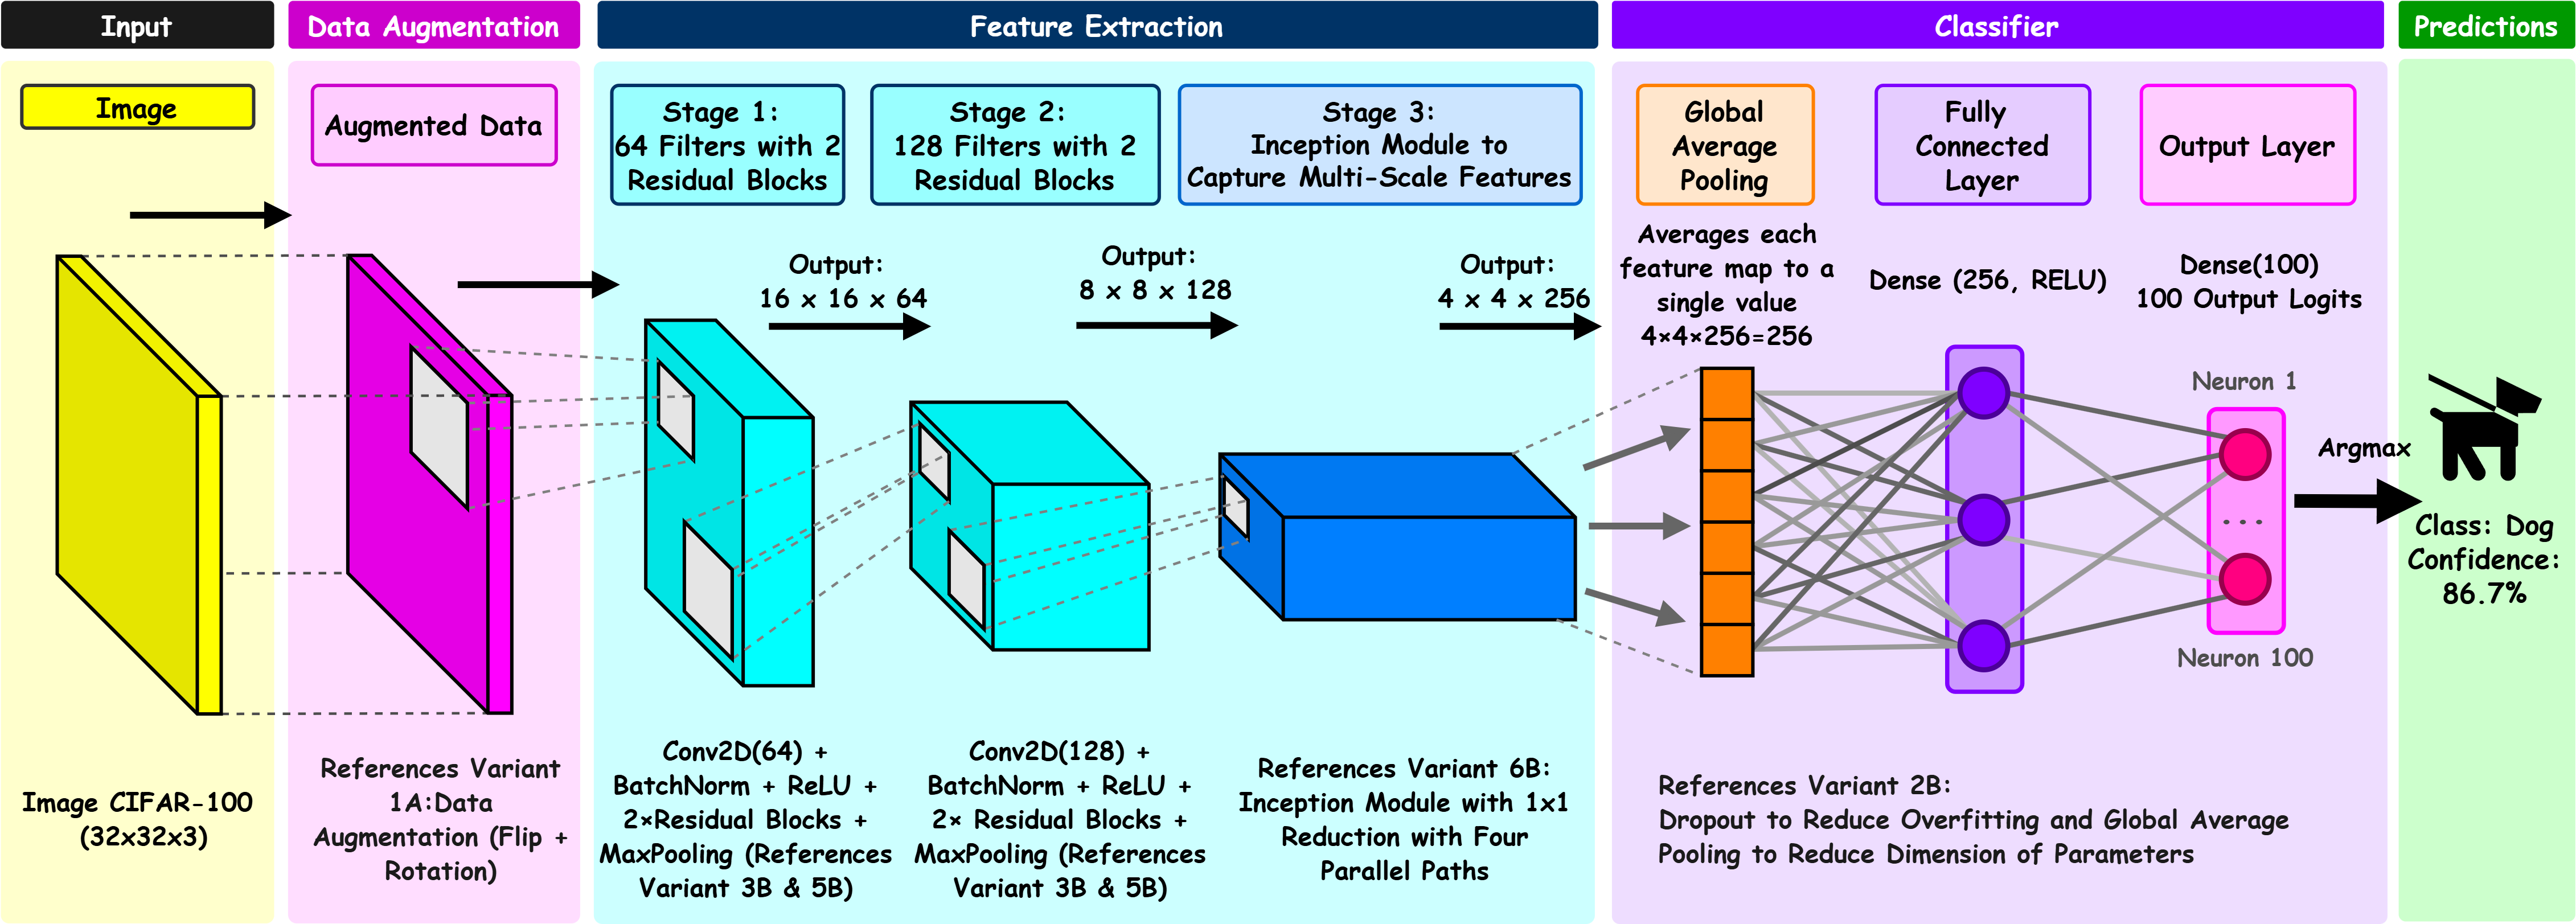

In [47]:
# Data Augmentation: Randomly flips and rotates images to artificially increase dataset variety
# References Variant 1A: Data Augmentation (Flip + Rotation)
data_augmentation = tf.keras.Sequential([tf.keras.layers.RandomFlip("horizontal"), tf.keras.layers.RandomRotation(0.1),])

# Residual Block: Two Convolution Layers with Batch Normalization and a Skip Connection
# References Variant 2A and 5B: Batch Normalization and 2 Residual Blocks per Stage
def residual_block(x, filters):
    skip_connection = x  # Save input for skip connection
    x = Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)  # Batch Normalization from Variant 2A
    x = tf.keras.layers.ReLU()(x)
    x = Conv2D(filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)  # Batch Normalization from Variant 2A
    if skip_connection.shape[-1] != filters:     # Project skip connection if channel mismatch
        skip_connection = Conv2D(filters, 1, padding='same')(skip_connection)
        skip_connection = tf.keras.layers.BatchNormalization()(skip_connection)
    x = Add()([x, skip_connection])              # Add skip connection to main path
    x = tf.keras.layers.ReLU()(x)
    return x

# Inception Block: Three Parallel Paths (1x1, 1x1 then 3x3, 1x1 then 5x5) Concatenated
# References Variant 6B: Inception Module with 1x1 Reduction
def inception_block(x, f1x1, f3x3_red, f3x3, f5x5_red, f5x5, f_pool):
    path_1 = Conv2D(f1x1, 1, padding='same', activation='relu')(x)
    path_2 = Conv2D(f3x3_red, 1, padding='same', activation='relu')(x)
    path_2 = Conv2D(f3x3, 3, padding='same', activation='relu')(path_2)
    path_3 = Conv2D(f5x5_red, 1, padding='same', activation='relu')(x)
    path_3 = Conv2D(f5x5, 5, padding='same', activation='relu')(path_3)
    path_4 = MaxPooling2D(3, strides=1, padding='same')(x)      # Pool path
    path_4 = Conv2D(f_pool, 1, padding='same', activation='relu')(path_4)
    return Concatenate()([path_1, path_2, path_3, path_4])

inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs) # Apply data augmentation from Variant 1A

# Stage 1: 64 Filters with 2 Residual Blocks
# References Variant 3B and 5B: Increased Filters (64) and 2 Residual Blocks per Stage
x = Conv2D(64, 3, padding='same')(x)
x = tf.keras.layers.BatchNormalization()(x)  # Batch Normalization from Variant 2A
x = tf.keras.layers.ReLU()(x)
x = residual_block(x, 64)  # Residual Block 1 from Variant 5B
x = residual_block(x, 64)  # Residual Block 2 from Variant 5B
x = MaxPooling2D(2, strides=2)(x)

# Stage 2: 128 Filters with 2 Residual Blocks
# References Variant 3B and 5B: Increased Filters (128) and 2 Residual Blocks per Stage
x = Conv2D(128, 3, padding='same')(x)
x = tf.keras.layers.BatchNormalization()(x)  # Batch Normalization from Variant 2A
x = tf.keras.layers.ReLU()(x)
x = residual_block(x, 128)  # Residual Block 1 from Variant 5B
x = residual_block(x, 128)  # Residual Block 2 from Variant 5B
x = MaxPooling2D(2, strides=2)(x)

# Stage 3: Inception Block to Capture Multi-Scale Features
# References Variant 6B: Inception Module with 1x1 Reduction
x = inception_block(x, f1x1=64, f3x3_red=64, f3x3=128, f5x5_red=32, f5x5=64, f_pool=32)
x = tf.keras.layers.BatchNormalization()(x)  # Batch Normalization from Variant 2A
x = MaxPooling2D(2, strides=2)(x)

# Classification Section
# References Variant 2B: Dropout to Reduce Overfitting
x = tf.keras.layers.GlobalAveragePooling2D()(x)  # Replaces Flatten to Reduce Parameters
x = Dense(256, activation='relu')(x) # Increased to 256 from Variant 3B
x = tf.keras.layers.Dropout(0.3)(x)  # Dropout from Variant 2B
outputs = Dense(100)(x) # Output Layer with 100 Classes

model_task_3 = Model(inputs, outputs)
print(model_task_3.summary())

Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_29      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_18       │ (None, 32, 32, 3) │          0 │ input_layer_29[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_217 (Conv2D) │ (None, 32, 32,    │      1,792 │ sequential_18[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_217[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_142 (ReLU)    │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_218 (Conv2D) │ (None, 32, 32,    │     36,928 │ re_lu_142[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_218[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_143 (ReLU)    │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_219 (Conv2D) │ (None, 32, 32,    │     36,928 │ re_lu_143[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_219[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_54 (Add)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ re_lu_142[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_144 (ReLU)    │ (None, 32, 32,    │          0 │ add_54[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_220 (Conv2D) │ (None, 32, 32,    │     36,928 │ re_lu_144[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_220[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_145 (ReLU)    │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_221 (Conv2D) │ (None, 32, 32,    │     36,928 │ re_lu_145[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_221[0][0]

 Total params: 1,068,260 (4.08 MB)

 Trainable params: 1,065,764 (4.07 MB)

 Non-trainable params: 2,496 (9.75 KB)

None


#### **Compile, Train and Evaluate the Model**

In [ ]:
# Training Parameters
epoch = 50
batchsize = 256

# CosineDecay gradually reduces learning rate from 0.001 to 0 over training
learning_rate_scheldule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.002,
    decay_steps=epoch * (50000 // batchsize)
)

# Compile Model for Task 3
model_task_3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate_scheldule),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Checkpoint: Saves the best model based on highest validation accuracy
task_3_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model_task3.keras',
    monitor='val_accuracy', # Monitor validation accuracy
    save_best_only=True, # Only save when validation accuracy improves
    mode='max',
    verbose=1
)

# Train the Model
start_time = time.time()
history_Task_3 = model_task_3.fit(
    train_images, train_labels,
    epochs=epoch,
    batch_size=batchsize,
    validation_data=(test_images, test_labels),
    callbacks=[task_3_checkpoint],
    verbose=1
)

end_time = time.time()
print(f"Total Training Time for Task 3: {(end_time - start_time) / 60:.2f} minutes")

#### **Evaluate and Plot the Performance Model**

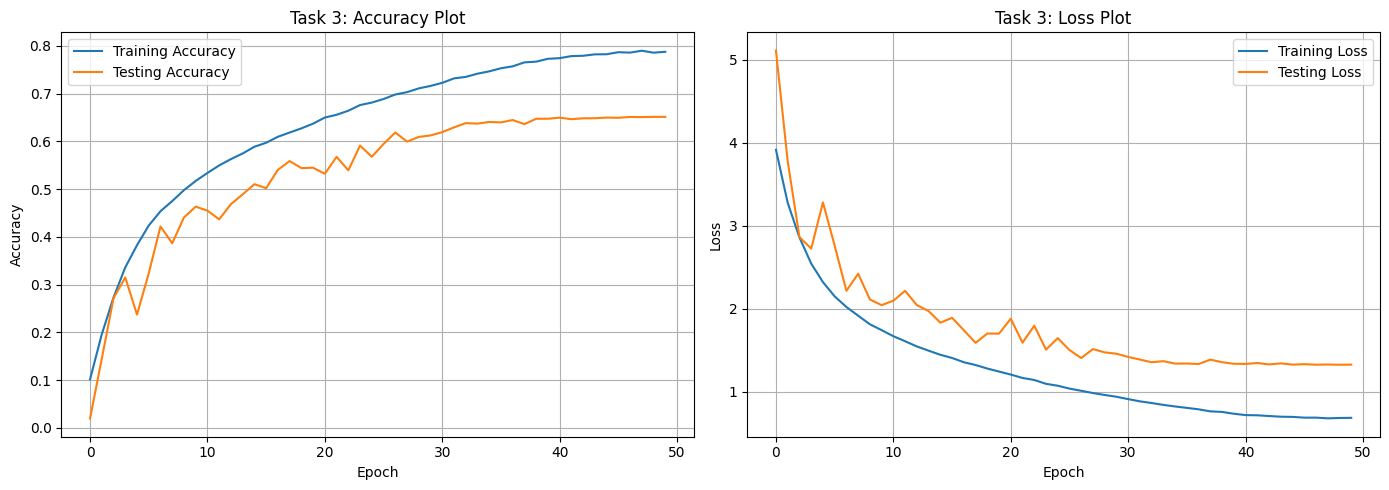

Task 3 Highest Training Dataset Accuracy : 78.97%
Task 3 Highest Test Dataset Accuracy : 65.11% at Epoch 49
Task 3 Lowest Training Dataset Loss : 0.6812
Task 3 Lowest Test Dataset Loss : 1.3269


In [54]:
# Generate Accuracy and Loss Plot
figure, (axis_1, axis_2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axis_1.plot(history_Task_3.history['accuracy'], label='Training Accuracy')
axis_1.plot(history_Task_3.history['val_accuracy'], label='Testing Accuracy')
axis_1.set_title('Task 3: Accuracy Plot')
axis_1.set_xlabel('Epoch')
axis_1.set_ylabel('Accuracy')
axis_1.legend()
axis_1.grid(True)

# Loss Plot
axis_2.plot(history_Task_3.history['loss'], label='Training Loss')
axis_2.plot(history_Task_3.history['val_loss'], label='Testing Loss')
axis_2.set_title('Task 3: Loss Plot')
axis_2.set_xlabel('Epoch')
axis_2.set_ylabel('Loss')
axis_2.legend()
axis_2.grid(True)

plt.tight_layout()
plt.show()

# Best Accuracy and Loss Results
highest_train_accuracy_task_3 = max(history_Task_3.history['accuracy'])
highest_test_accuracy_task_3  = max(history_Task_3.history['val_accuracy'])
epoch_occurrence_task_3       = history_Task_3.history['val_accuracy'].index(highest_test_accuracy_task_3) + 1
lowest_train_loss_task_3      = min(history_Task_3.history['loss'])
lowest_test_loss_task_3       = min(history_Task_3.history['val_loss'])

print(f"Task 3 Highest Training Dataset Accuracy : {highest_train_accuracy_task_3 * 100:.2f}%")
print(f"Task 3 Highest Test Dataset Accuracy : {highest_test_accuracy_task_3 * 100:.2f}% at Epoch {epoch_occurrence_task_3}")
print(f"Task 3 Lowest Training Dataset Loss : {lowest_train_loss_task_3:.4f}")
print(f"Task 3 Lowest Test Dataset Loss : {lowest_test_loss_task_3:.4f}")

***

### **Task 4: Explore Image Classification**

Task 4 builds on Task 3 by introducing three novel techniques to improve accuracy and training efficiency. The core architecture retains the residual and inception design from Task 3, with the following key additions:

- Mixed Precision Training (float16): Speeds up GPU training with minimal
  accuracy impact
- Mixup Augmentation (Zhang et al., 2018): Blends pairs of training images
  and their labels to improve generalisation
- Squeeze-and-Excitation Blocks (Hu et al., 2018): Recalibrates channel-wise
  feature responses by learning which channels are most important
- Factorised 5x5 Convolutions: Two stacked 3x3 convolutions replace the 5x5
  in the inception block, reducing parameters while maintaining the same receptive field
- Fourth Pooling Path in Inception Block: Adds a MaxPooling branch to capture
  spatial context
- Strided Convolutions replace MaxPooling: Stride = 2 in residual blocks handles downsampling more efficiently
- Label Smoothing (Szegedy et al., 2016): prevents overconfident predictions
  by softening the target distribution
- AdamW Optimizer:  Adam with decoupled weight decay for better regularisation
- tf.data Pipeline: eplaces numpy arrays with cached, prefetched dataset
  pipeline for improved throughput

The Architecture of Model 4 is shown below: 

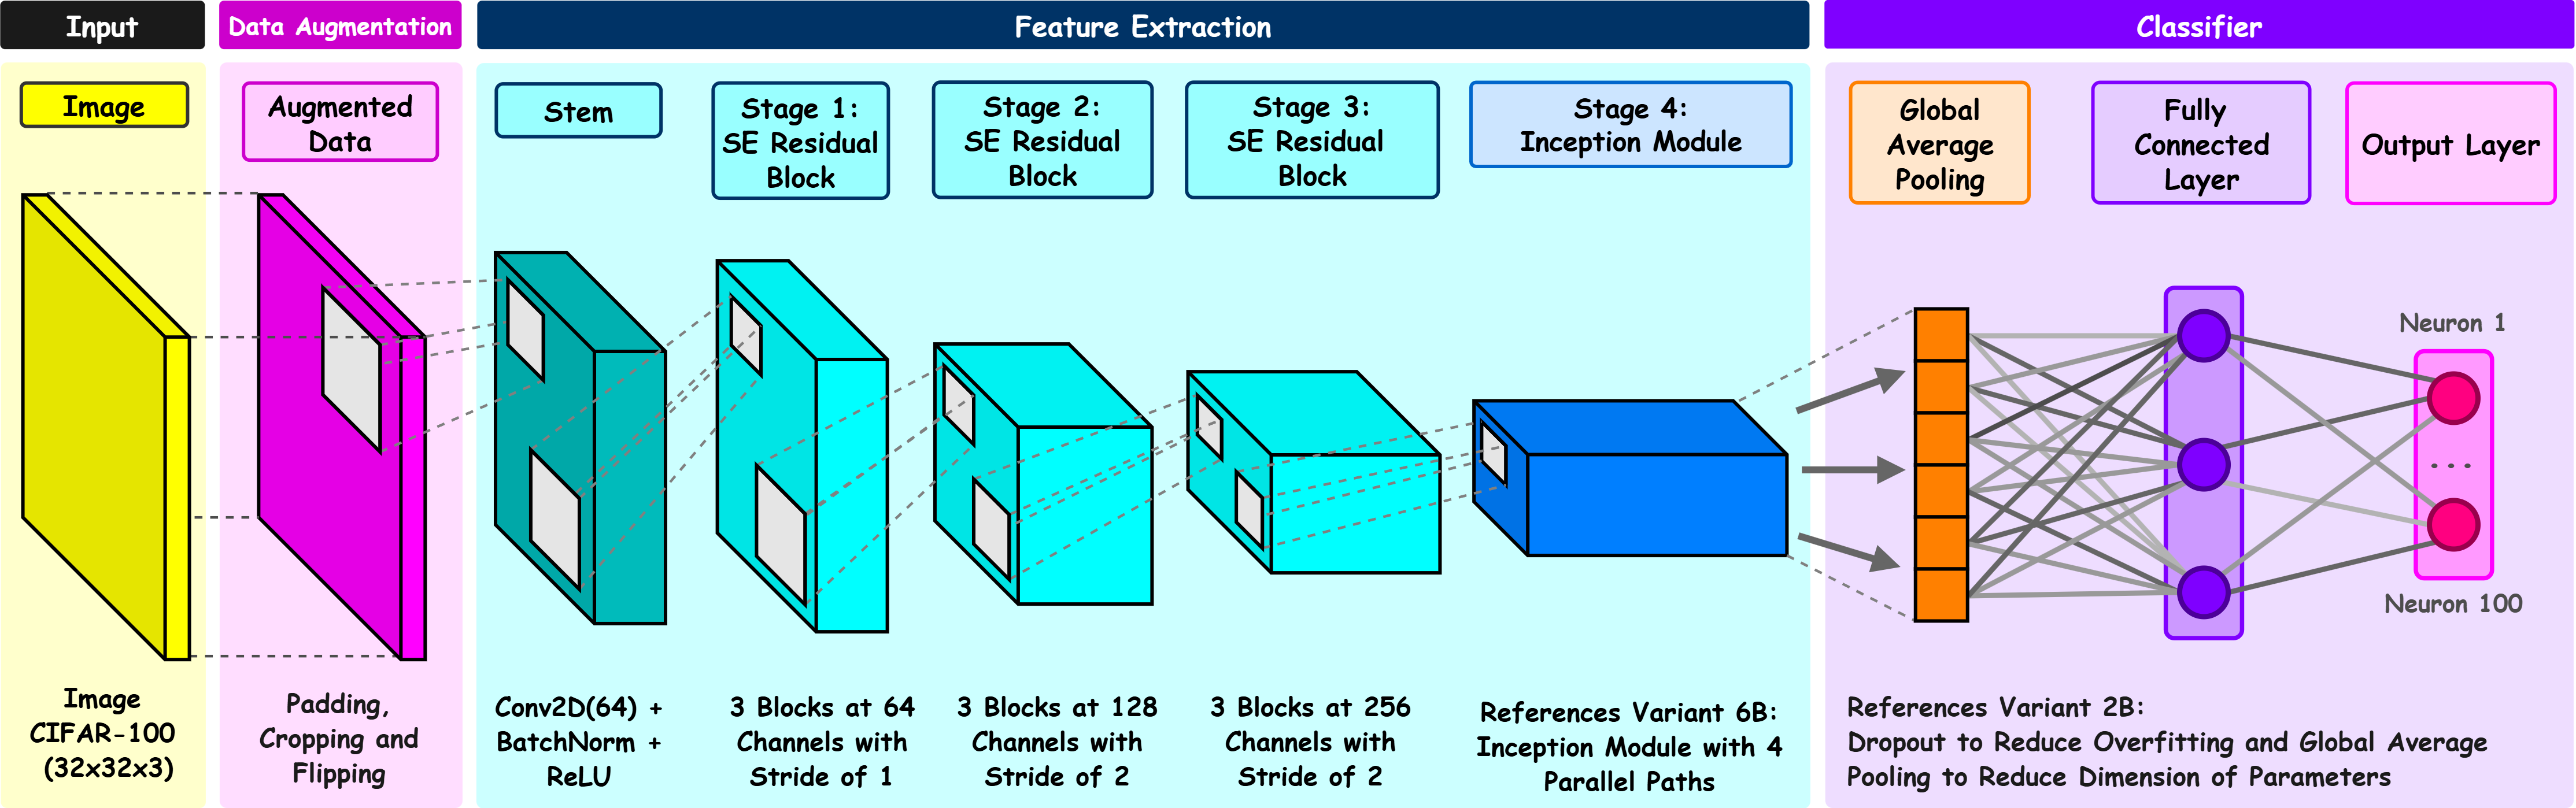

In [39]:
import tensorflow as tf
from tensorflow.keras.layers import (Conv2D, Dense, MaxPooling2D, Add, Concatenate, Input, BatchNormalization, ReLU, GlobalAveragePooling2D, Reshape,Multiply, Dropout)
from tensorflow.keras.models import Model

# Mixed Precision: Speeds up training on GPU by using float16
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Mixup: Blends two random training images and their labels to improve generalisation
# References: Zhang et al. (2018)
def mixup_data(x, y, alpha=0.2):
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)
    batch_size = tf.shape(x)[0]
    indices   = tf.random.shuffle(tf.range(batch_size))  # Shuffle indices for pairing
    x_shuffled = tf.gather(x, indices)
    y_shuffled = tf.gather(y, indices)
    g1  = tf.random.gamma([], alpha)
    g2  = tf.random.gamma([], alpha)
    lam = g1 / (g1 + g2)                                 # Mixing coefficient from Beta distribution
    x_mixed = lam * x + (1.0 - lam) * x_shuffled         # Blend images
    y_mixed = lam * y + (1.0 - lam) * y_shuffled         # Blend labels
    return x_mixed, y_mixed

# One-hot encode labels for Mixup compatibility
labels_onehot_train = tf.keras.utils.to_categorical(train_labels, 100)
labels_onehot_test  = tf.keras.utils.to_categorical(test_labels, 100)

# Data Pipeline: cache, shuffle, batch, apply Mixup, prefetch for performance
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_images, labels_onehot_train))
    .cache()
    .shuffle(50000)
    .batch(batchsize)
    .map(lambda x, y: mixup_data(x, y, alpha=0.2), num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_images, labels_onehot_test))
    .batch(batchsize)
    .prefetch(tf.data.AUTOTUNE)
)

# Squeeze-and-Excitation Block: Recalibrates channel-wise feature responses
# References: Hu et al. (2018)
def squeeze_and_excitation_block(x, ratio=16):
    filters = x.shape[-1]
    squeeze_and_excitation = GlobalAveragePooling2D()(x) # Squeeze: global average per channel
    squeeze_and_excitation = Dense(filters // ratio, activation='relu')(squeeze_and_excitation) # Excitation: reduce
    squeeze_and_excitation = Dense(filters, activation='sigmoid')(squeeze_and_excitation) # Excitation: expand
    squeeze_and_excitation = Reshape((1, 1, filters))(squeeze_and_excitation) # Reshape for multiplication
    return Multiply()([x, squeeze_and_excitation]) # Scale original feature maps

# GPU-side Data Augmentation: Pad, crop and flip applied on device
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.ZeroPadding2D(4),
    tf.keras.layers.RandomCrop(32, 32),
    tf.keras.layers.RandomFlip("horizontal"),
])

# Residual Block with optional Squeeze-and-Excitation
# References Variant 5B: 2 Residual Blocks per Stage and stride replaces MaxPooling
def residual_block(x, filters, stride=1, use_se=True):
    shortcut = x
    x = Conv2D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    if use_se:
        x = squeeze_and_excitation_block(x) # Apply SE block before addition
    if stride != 1 or shortcut.shape[-1] != filters: # Project shortcut if mismatch
        shortcut = Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)
    x = Add()([x, shortcut]) # Add shortcut to main path
    x = ReLU()(x)
    return x

# Inception Block: Four paths with 5x5 factorised into two stacked 3x3 convolutions
# References Variant 6B: Inception Module with 1x1 Reduction
def inception_block(x, f1x1, f3x3_red, f3x3, f5x5_red, f5x5, f_pool):
    path_1 = Conv2D(f1x1, 1, padding='same')(x)               # 1x1 path
    path_1 = BatchNormalization()(path_1)
    path_1 = ReLU()(path_1)
    path_2 = Conv2D(f3x3_red, 1, padding='same')(x)           # 1x1 reduction
    path_2 = BatchNormalization()(path_2)
    path_2 = ReLU()(path_2)
    path_2 = Conv2D(f3x3, 3, padding='same')(path_2)          # 3x3 path
    path_2 = BatchNormalization()(path_2)
    path_2 = ReLU()(path_2)
    path_3 = Conv2D(f5x5_red, 1, padding='same')(x)           # 1x1 reduction
    path_3 = BatchNormalization()(path_3)
    path_3 = ReLU()(path_3)
    path_3 = Conv2D(f5x5, 3, padding='same')(path_3)          # First 3x3
    path_3 = BatchNormalization()(path_3)
    path_3 = ReLU()(path_3)
    path_3 = Conv2D(f5x5, 3, padding='same')(path_3)          # Second 3x3
    path_3 = BatchNormalization()(path_3)
    path_3 = ReLU()(path_3)
    path_4 = MaxPooling2D(3, strides=1, padding='same')(x)    # Pool path
    path_4 = Conv2D(f_pool, 1, padding='same')(path_4)        # 1x1 reduction on pool
    path_4 = BatchNormalization()(path_4)
    path_4 = ReLU()(path_4)
    return Concatenate()([path_1, path_2, path_3, path_4])    # Concatenate all paths

# Build Model
inputs = Input(shape=(32, 32, 3))
x = data_augmentation(inputs) # Apply GPU-side augmentation

# Stem: Initial Convolution to Process raw pixels into initial feature maps
x = Conv2D(64, 3, padding='same')(x)
x = BatchNormalization()(x)
x = ReLU()(x)

# Stage 1: 64 Filters with 3 Residual Blocks at 32x32
x = residual_block(x, 64)  # Residual Block 1
x = residual_block(x, 64)  # Residual Block 2
x = residual_block(x, 64)  # Residual Block 3

# Stage 2: 128 Filters, 3 Residual Blocks at 16x16 (stride = 2 replaces MaxPooling)
x = residual_block(x, 128, stride=2) # Residual Block 1 with Downsample
x = residual_block(x, 128)  # Residual Block 2
x = residual_block(x, 128)  # Residual Block 3

# Stage 3: 256 Filters, 3 Residual Blocks at 8x8 (stride = 2 replaces MaxPooling)
x = residual_block(x, 256, stride=2) # Residual Block 1, Downsample
x = residual_block(x, 256) # Residual Block 2
x = residual_block(x, 256) # Residual Block 3

# Stage 4: Inception Block with SE Recalibration
x = inception_block(x, f1x1=128, f3x3_red=128, f3x3=192, f5x5_red=32, f5x5=96, f_pool=64)
x = squeeze_and_excitation_block(x) # Squeeze and Excitation recalibration after inception

# Classification Section
x = GlobalAveragePooling2D()(x) # Replaces Flatten to Reduce Parameters
x = Dropout(0.2)(x) # Apply Dropout to Reduce Overfitting
outputs = Dense(100, activation='softmax', dtype='float32')(x) # float32 for mixed-precision stability

model_task_4 = Model(inputs, outputs)

# Compile Model with Label Smoothing, AdamW,  XLA
# References: Szegedy et al. (2016) for Label Smoothing
model_task_4.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy'],
    jit_compile=True
)

print(model_task_4.summary())

Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_27      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_17       │ (None, 32, 32, 3) │          0 │ input_layer_27[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_189 (Conv2D) │ (None, 32, 32,    │      1,792 │ sequential_17[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_189[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_116 (ReLU)    │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_190 (Conv2D) │ (None, 32, 32,    │     36,928 │ re_lu_116[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_190[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_117 (ReLU)    │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_191 (Conv2D) │ (None, 32, 32,    │     36,928 │ re_lu_117[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_191[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_95 (Dense)    │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_96 (Dense)    │ (None, 64)        │        320 │ dense_95[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_30          │ (None, 1, 1, 64)  │          0 │ dense_96[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_30         │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Multiply)          │ 64)               │            │ reshape_30[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_45 (Add)        │ (None, 32, 32,    │          0 │ multiply_30[0][0… │
│                     │ 64)               │            │ re_lu_116[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_118 (ReLU)    │ (None, 32, 32,    │          0 │ add_45[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,871,254 (18.58 MB)

 Trainable params: 4,863,510 (18.55 MB)

 Non-trainable params: 7,744 (30.25 KB)

None


#### **Train the Task 4 Model**

In [ ]:
# Training Parameters
epoch = 40
batchsize = 256

# Checkpoint: Saves the best model based on highest validation accuracy
checkpoint_task_4 = tf.keras.callbacks.ModelCheckpoint(
    'best_model_task4.keras',
    monitor='val_accuracy',   # Monitor validation accuracy
    save_best_only=True,      # Only save when validation accuracy improves
    mode='max',
    verbose=1
)

# ReduceLROnPlateau: Reduces learning rate by half if validation accuracy does not improve
reduce_lr_task_4 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,               # Reduce learning rate by half
    patience=5,               # Wait 5 epochs before reducing
    min_lr=1e-6,              # Minimum learning rate
    verbose=1
)

start_time = time.time()
history_Task_4 = model_task_4.fit(
    train_ds,
    epochs=epoch,
    validation_data=test_ds,
    callbacks=[checkpoint_task_4, reduce_lr_task_4],  # Apply checkpoint and LR callbacks
    verbose=1
)
end_time = time.time()
print(f"Total Training Time for Task 4: {(end_time - start_time) / 60:.2f} minutes")


#### **Evaluate the Task 4 Model Accuracy and Loss Results**

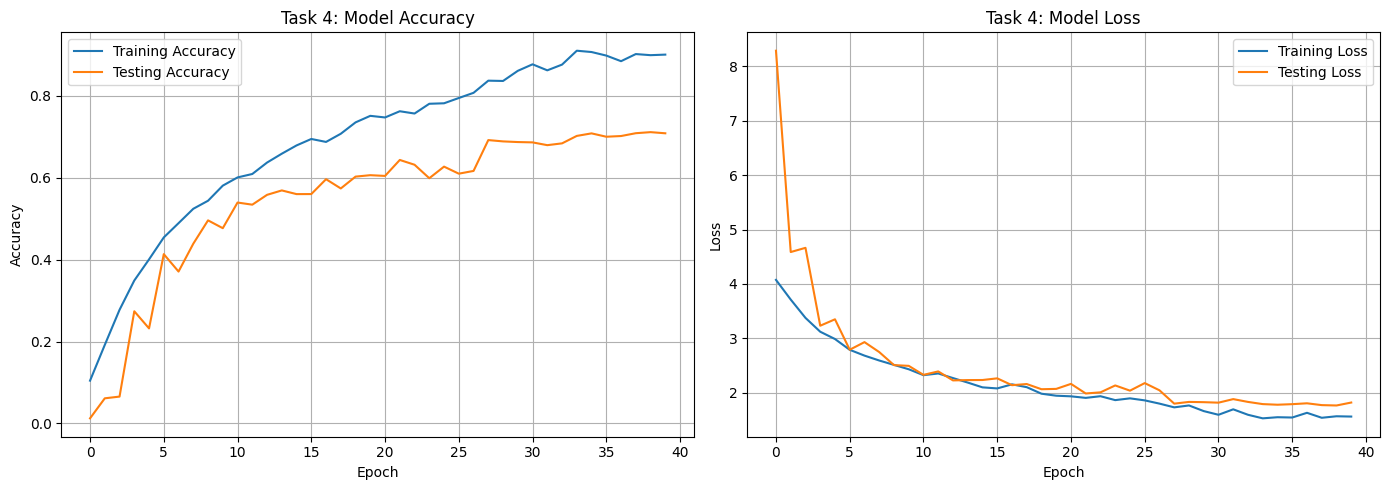

Task 4 Highest Training Dataset Accuracy : 91.00%
Task 4 Highest Test Dataset Accuracy : 71.12% at Epoch 39
Task 4 Lowest Training Dataset Loss : 1.5295
Task 4 Lowest Test Dataset Loss : 1.7659

Improvement over Task 3 : 6.01%
Task 3 Highest Test Dataset Accuracy : 65.11%
Task 3 Lowest Test Dataset Loss : 1.3269


In [53]:
# Best Accuracy Results
highest_train_accuracy_task_4 = max(history_Task_4.history['accuracy'])
highest_test_accuracy_task_4  = max(history_Task_4.history['val_accuracy'])
epoch_occurrence_task_4       = history_Task_4.history['val_accuracy'].index(highest_test_accuracy_task_4) + 1

# Generate Accuracy and Loss Plot
figure, (axis_1, axis_2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axis_1.plot(history_Task_4.history['accuracy'], label='Training Accuracy')
axis_1.plot(history_Task_4.history['val_accuracy'], label='Testing Accuracy')
axis_1.set_title('Task 4: Model Accuracy')
axis_1.set_xlabel('Epoch')
axis_1.set_ylabel('Accuracy')
axis_1.legend()
axis_1.grid(True)

# Loss Plot
axis_2.plot(history_Task_4.history['loss'], label='Training Loss')
axis_2.plot(history_Task_4.history['val_loss'], label='Testing Loss')
axis_2.set_title('Task 4: Model Loss')
axis_2.set_xlabel('Epoch')
axis_2.set_ylabel('Loss')
axis_2.legend()
axis_2.grid(True)

plt.tight_layout()
plt.show()

# Best Accuracy and Loss Results
highest_train_accuracy_task_4 = max(history_Task_4.history['accuracy'])
highest_test_accuracy_task_4 = max(history_Task_4.history['val_accuracy'])
epoch_occurrence_task_4 = history_Task_4.history['val_accuracy'].index(highest_test_accuracy_task_4) + 1
lowest_train_loss_task_4 = min(history_Task_4.history['loss'])
lowest_test_loss_task_4 = min(history_Task_4.history['val_loss'])

# Compare Task 4 against Task 3
print(f"Task 4 Highest Training Dataset Accuracy : {highest_train_accuracy_task_4 * 100:.2f}%")
print(f"Task 4 Highest Test Dataset Accuracy : {highest_test_accuracy_task_4 * 100:.2f}% at Epoch {epoch_occurrence_task_4}")
print(f"Task 4 Lowest Training Dataset Loss : {lowest_train_loss_task_4:.4f}")
print(f"Task 4 Lowest Test Dataset Loss : {lowest_test_loss_task_4:.4f}")
print(f"\nImprovement over Task 3 : {(highest_test_accuracy_task_4 - highest_test_accuracy_task_3) * 100:.2f}%")
print(f"Task 3 Highest Test Dataset Accuracy : {highest_test_accuracy_task_3 * 100:.2f}%")
print(f"Task 3 Lowest Test Dataset Loss : {lowest_test_loss_task_3:.4f}")